# Bayesian optimization of an heteroschedastic noisy objective with bagging ensembles of surrogate models 

In [1]:
import matplotlib.pyplot as plt
from scipy.special import expit
import numpy as np
from sklearn.utils import check_random_state

LOWER_BOUNDS = [-10]
UPPER_BOUNDS = [10]
quantile_high = 0.90
quantile_low = 0.19


def latin_hypercube_sampling(n_samples, lower_bounds, upper_bounds, random_state=None):
    rng = check_random_state(random_state)
    n_dims = len(lower_bounds)
    result = np.zeros((n_samples, n_dims))
    for dim in range(n_dims):
        permuted = rng.permutation(n_samples)
        intervals = np.linspace(lower_bounds[dim], upper_bounds[dim], n_samples + 1)
        points = intervals[:-1] + rng.uniform(size=n_samples) * (
            intervals[1:] - intervals[:-1]
        )
        result[:, dim] = points[permuted]
    return result


latin_hypercube_sampling(10, LOWER_BOUNDS, UPPER_BOUNDS, random_state=0)

array([[-4.07267448],
       [ 6.14207212],
       [-0.41654992],
       [ 8.1742586 ],
       [-6.216454  ],
       [ 3.13608912],
       [ 5.85119328],
       [-3.23311696],
       [-9.12482558],
       [ 1.05778984]])

(np.float64(-6.495271862114881), np.float64(11.637925324699879))

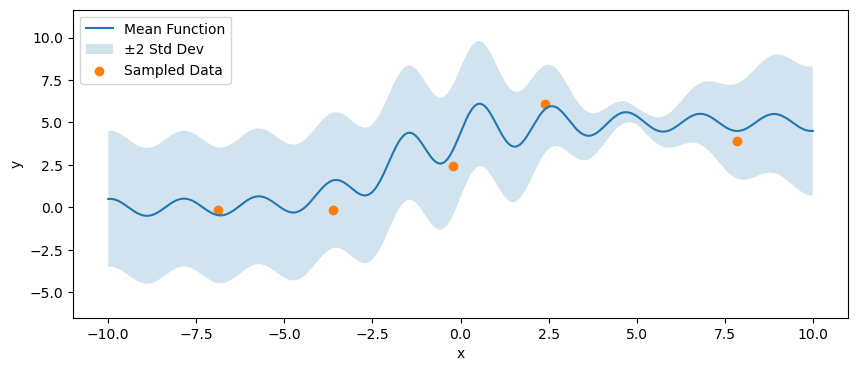

In [2]:
def data_generating_process_parameters(X):
    assert X.ndim in (1, 2)
    if X.ndim == 2:
        assert X.shape[1] == 1, X.shape
        x = X[:, 0]
    else:
        x = X

    assert x.ndim == 1, x.shape
    mean = np.sin(3 * x) * (np.exp(-(0.1 * x**2)) + 0.5) + 5 * expit(x + 2)
    std = 2 * expit(np.abs(x - 5) - 2)
    return mean, std


def sample_data_from_dgp(sample_size=12, random_state=None):
    rng = check_random_state(random_state)
    X = latin_hypercube_sampling(
        sample_size, LOWER_BOUNDS, UPPER_BOUNDS, random_state=rng
    )
    return X, conditional_sample_data_from_dgp(X, random_state=rng)


def conditional_sample_data_from_dgp(X, random_state=None):
    rng = check_random_state(random_state)
    mean, std = data_generating_process_parameters(X)
    return rng.normal(loc=mean, scale=std)


sample_size = 5
X_initial, y_initial = sample_data_from_dgp(sample_size, random_state=42)

x_grid = np.linspace(LOWER_BOUNDS[0], UPPER_BOUNDS[0], 1000)
mean_grid, std_grid = data_generating_process_parameters(x_grid)


def plot_dgp(X, y, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x_grid, mean_grid, label="Mean Function")
    ax.fill_between(
        x_grid,
        mean_grid - 2 * std_grid,
        mean_grid + 2 * std_grid,
        alpha=0.2,
        label="±2 Std Dev",
    )
    ax.scatter(X, y, label="Sampled Data")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    y_lim = (mean_grid - 3 * std_grid).min(), (mean_grid + 3 * std_grid).max()
    ax.set_ylim(*y_lim)
    ax.legend()
    return y_lim


plot_dgp(X_initial, y_initial)

In [3]:
mean_grid, std_grid = data_generating_process_parameters(x_grid.reshape(-1, 1))
best_idx = mean_grid.argmax()
true_x_max = x_grid[best_idx]
true_y_max = mean_grid[best_idx]

true_x_max, true_y_max

(np.float64(0.5505505505505504), np.float64(6.10339365320972))

In [4]:
def ensemble_quantile_prediction(model, X, quantile=quantile_high):
    """Compute the quantile prediction of an ensemble model."""
    return np.quantile(
        np.concatenate(
            [estimator.predict(X).reshape(-1, 1) for estimator in model.estimators_],
            axis=1,
        ),
        quantile,
        axis=1,
    )

In [5]:
def ensemble_predictions(model, X, quantiles=(quantile_low, quantile_high)):
    """Compute the quantile prediction of an ensemble model."""
    all_predictions = np.concatenate(
        [estimator.predict(X).reshape(-1, 1) for estimator in model.estimators_],
        axis=1,
    )
    prediction_bounds = np.quantile(
        all_predictions,
        quantiles,
        axis=1,
    )
    assert prediction_bounds.shape == (2, X.shape[0]), prediction_bounds.shape
    low, high = prediction_bounds[0], prediction_bounds[1]

    trimming_mask = (all_predictions >= low.reshape(-1, 1)) & (
        all_predictions <= high.reshape(-1, 1)
    )
    trimmed_means = np.sum(all_predictions * trimming_mask, axis=1) / np.sum(
        trimming_mask, axis=1
    )
    return trimmed_means, low, high



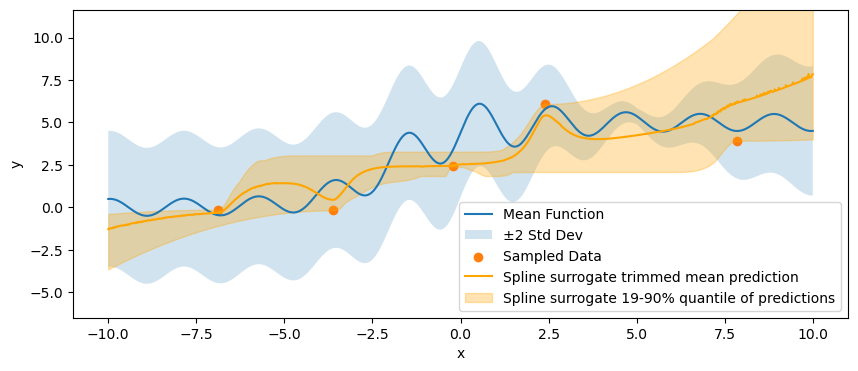

In [6]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingRegressor

surrogate_spline = BaggingRegressor(
    make_pipeline(
        SplineTransformer(degree=3, n_knots=20, extrapolation="linear"),
        PolynomialFeatures(degree=2, include_bias=False),
        # RidgeCV(alphas=np.logspace(-6, 6, 13)),
        Ridge(alpha=1e-6),
    ),
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
).fit(X_initial.reshape(-1, 1), y_initial)
fig, ax = plt.subplots(figsize=(10, 4))
plot_dgp(X_initial, y_initial, ax=ax)

trimmed_mean, low_bound, high_bound = ensemble_predictions(
    surrogate_spline, x_grid.reshape(-1, 1), quantiles=(quantile_low, quantile_high)
)
ax.plot(
    x_grid,
    trimmed_mean,
    label="Spline surrogate trimmed mean prediction",
    color="orange",
)
ax.fill_between(
    x_grid,
    low_bound,
    high_bound,
    color="orange",
    alpha=0.3,
    label=f"Spline surrogate {quantile_low*100:.0f}-{quantile_high*100:.0f}% quantile of predictions",
)
_ = ax.legend()

In [7]:
import dlib


def find_next_evaluation_point_maxlipo_tr(
    surrogate_model,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    quantile=quantile_high,
    max_iter=100,
):
    def objective_function(*x):
        x_reshaped = np.array(x).reshape(1, -1)
        q_pred = ensemble_quantile_prediction(
            surrogate_model, x_reshaped, quantile=quantile
        )
        return q_pred[0]

    x, _ = dlib.find_max_global(
        objective_function,
        lower_bounds,
        upper_bounds,
        max_iter,
    )
    return np.array(x)


find_next_evaluation_point_maxlipo_tr(surrogate_spline)

array([10.])

In [8]:
def find_next_evaluation_point_latin_hypercube_montecarlo(
    surrogate_model,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    sample_size=100,
    high_batch_size=5,
    wide_batch_size=2,
    random_state=None,
    quantiles=(quantile_low, quantile_high),
):
    X_candidates = latin_hypercube_sampling(
        sample_size, lower_bounds, upper_bounds, random_state=random_state
    )
    trimmed_mean, low_bound, high_bound = ensemble_predictions(
        surrogate_model, X_candidates, quantiles=quantiles
    )
    # Maximize by selecting the top `high_batch_size` candidates
    assert high_batch_size >= 1, high_batch_size
    selected_candidate_indices = np.argpartition(high_bound, -high_batch_size)[
        -high_batch_size:
    ]

    if wide_batch_size >= 1:
        width = high_bound - low_bound
        wide_selected_indices = np.argpartition(width, -wide_batch_size)[
            -wide_batch_size:
        ]
        selected_candidate_indices = np.concatenate(
            (selected_candidate_indices, wide_selected_indices)
        )

    # Find the trimmed mean maximum among all the candidates
    best_index = np.argmax(trimmed_mean)

    return (
        X_candidates[selected_candidate_indices, :],
        X_candidates[best_index, :],
        trimmed_mean[best_index],
    )


find_next_evaluation_point_latin_hypercube_montecarlo(surrogate_spline)

(array([[9.12657107],
        [9.23695336],
        [9.4888838 ],
        [9.64918491],
        [9.88054727],
        [9.64918491],
        [9.88054727]]),
 array([9.88054727]),
 np.float64(7.733773873190738))

In [9]:
def find_max_expected_value(
    surrogate_model,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    max_iter=100,
):
    def objective_function(*x):
        x_reshaped = np.array(x).reshape(1, -1)
        mean_pred = surrogate_model.predict(x_reshaped)
        return mean_pred[0]

    x, y = dlib.find_max_global(
        objective_function,
        lower_bounds,
        upper_bounds,
        max_iter,
    )
    return np.array(x), y


find_max_expected_value(surrogate_spline)

(array([10.]), 9.425128285468787)

Iteration 1: 5 explored points; current max expected value at x=9.946, y=7.667; next observation(s) at x=[9.402 9.672 9.946 9.946], y=[5.185 2.247 3.244 2.257]
Iteration 2: 9 explored points; current max expected value at x=8.892, y=6.481; next observation(s) at x=[8.639 9.009 8.892 8.892], y=[6.231 5.63  4.96  5.669]
Iteration 3: 13 explored points; current max expected value at x=8.348, y=6.917; next observation(s) at x=[7.689 7.821 8.07  7.689], y=[5.276 1.373 4.088 4.467]
Iteration 4: 17 explored points; current max expected value at x=6.927, y=35.531; next observation(s) at x=[6.521 6.927 6.741 6.741], y=[5.311 5.429 5.258 5.089]
Iteration 5: 21 explored points; current max expected value at x=7.248, y=12.147; next observation(s) at x=[5.631 5.937 6.007 5.631], y=[4.737 4.237 4.119 4.069]
Iteration 6: 25 explored points; current max expected value at x=7.298, y=10.296; next observation(s) at x=[7.437 7.17  7.298 4.691], y=[4.325 4.334 6.668 5.848]
Iteration 7: 29 explored points; 

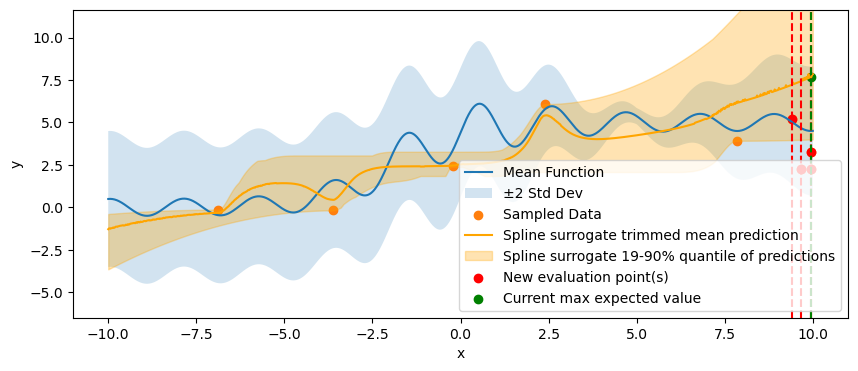

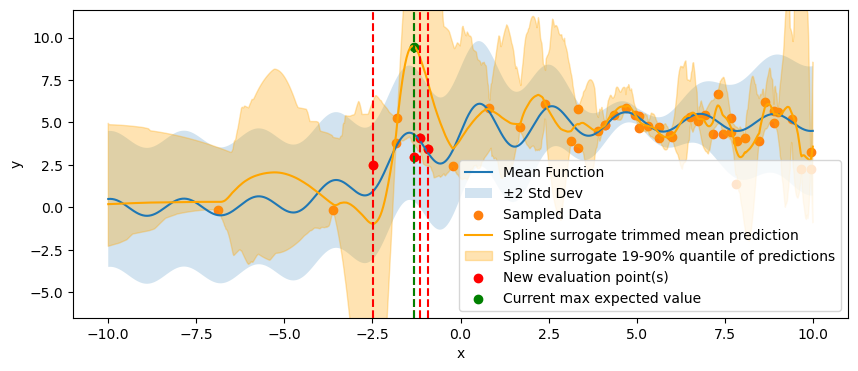

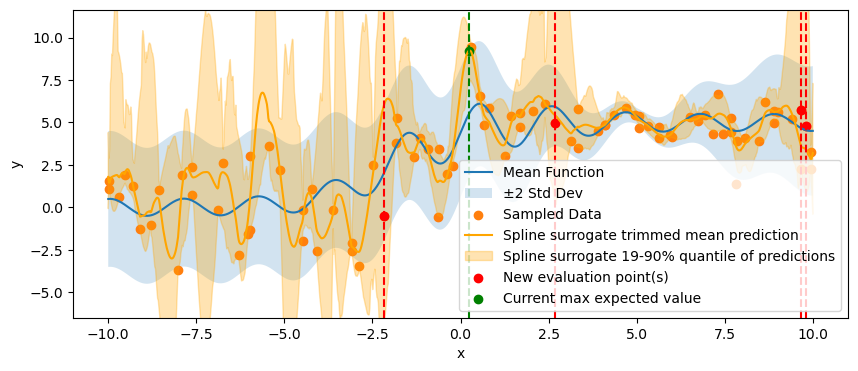

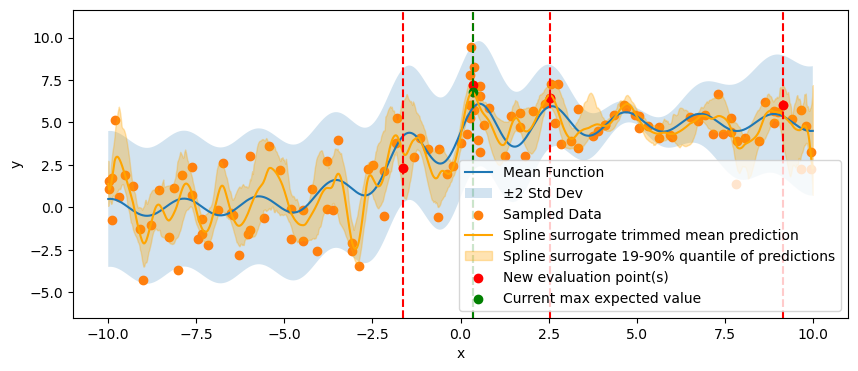

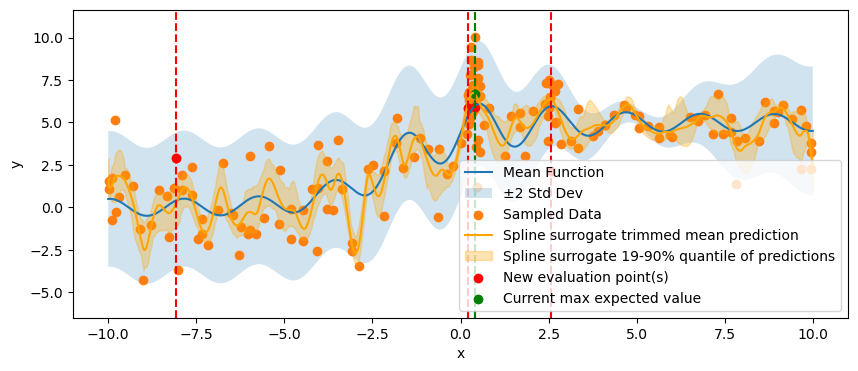

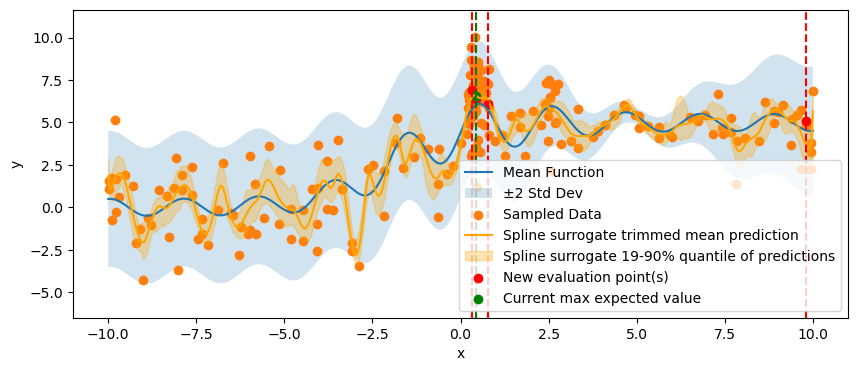

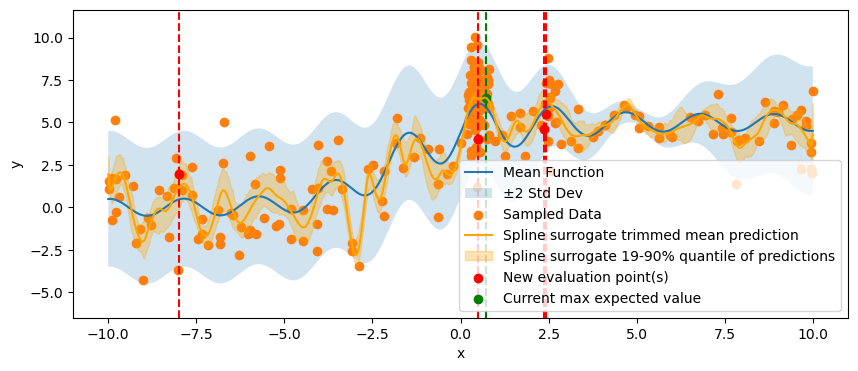

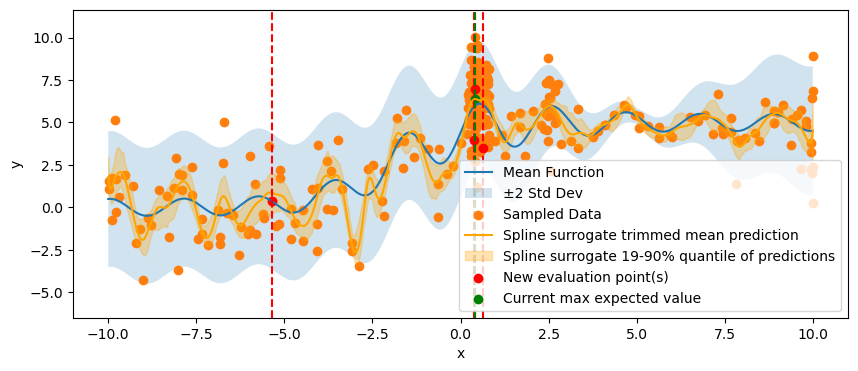

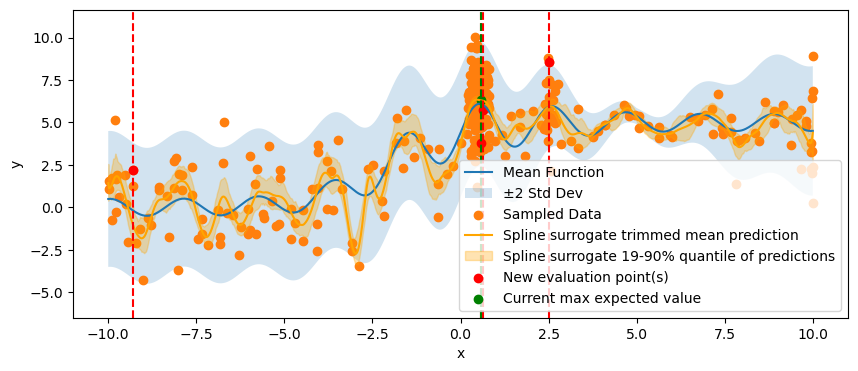

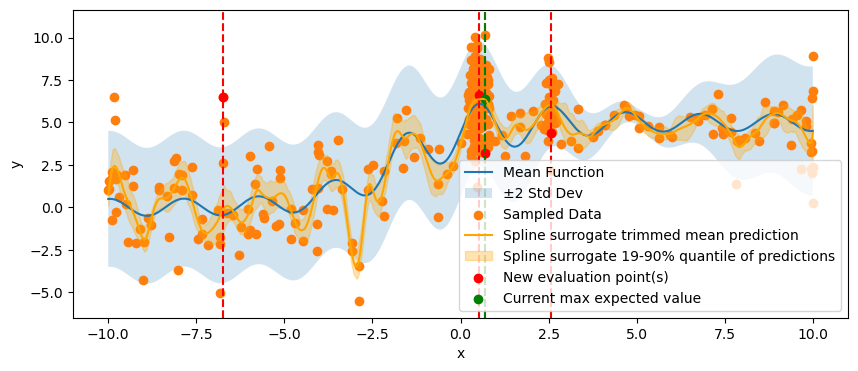

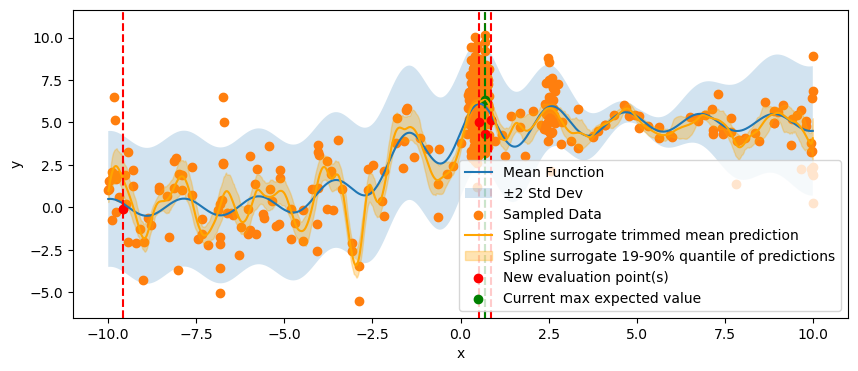

In [10]:
X_explored = X_initial.copy()
y_explored = y_initial.copy()

rng = check_random_state(0)
max_iter = 100
for iter_idx in range(max_iter):
    surrogate_spline.fit(X_explored, y_explored)
    # X_best, y_best = find_max_expected_value(surrogate_spline)
    X_next, X_best, y_best = find_next_evaluation_point_latin_hypercube_montecarlo(
        surrogate_spline,
        high_batch_size=3,
        wide_batch_size=1,
        sample_size=100,
        random_state=rng,
    )
    x_best = X_best.ravel()[0]
    y_next = conditional_sample_data_from_dgp(X_next, random_state=rng)
    print(
        f"Iteration {iter_idx + 1}: "
        f"{X_explored.shape[0]} explored points; "
        f"current max expected value at x={x_best:.3f}, y={y_best:.3f}; "
        f"next observation(s) at x={X_next.ravel().squeeze().round(3)}, y={y_next.round(3)}"
    )
    X_explored = np.concatenate([X_explored, X_next], axis=0)
    y_explored = np.concatenate([y_explored, y_next])
    if iter_idx % 10 == 0 or iter_idx == max_iter - 1:
        fig, ax = plt.subplots(figsize=(10, 4))
        y_lim = plot_dgp(X_explored, y_explored, ax=ax)
        trimmed_mean, low_bound, high_bound = ensemble_predictions(
            surrogate_spline, x_grid.reshape(-1, 1), quantiles=(quantile_low, quantile_high)
        )
        ax.plot(
            x_grid,
            trimmed_mean,
            label="Spline surrogate trimmed mean prediction",
            color="orange",
        )
        ax.fill_between(
            x_grid,
            low_bound,
            high_bound,
            color="orange",
            alpha=0.3,
            label=f"Spline surrogate {quantile_low*100:.0f}-{quantile_high*100:.0f}% quantile of predictions",
        )
        ax.vlines(
            X_next,
            ymin=y_lim[0],
            ymax=y_lim[1],
            colors="red",
            linestyles="dashed",
        )
        ax.scatter(X_next, y_next, color="red", label="New evaluation point(s)")
        ax.vlines(
            x_best,
            ymin=y_lim[0],
            ymax=y_lim[1],
            colors="green",
            linestyles="dashed",
        )
        ax.scatter([x_best], [y_best], color="green", label="Current max expected value")
        _ = ax.legend()

In [11]:
# from sklearn.preprocessing import KBinsDiscretizer
# from sklearn.ensemble import RandomForestRegressor

# surrogate_rf = RandomForestRegressor().fit(X_initial.reshape(-1, 1), y_initial)
# mean_pred_rf = surrogate_rf.predict(x_grid.reshape(-1, 1))
# fig, ax = plt.subplots(figsize=(10, 4))
# plot_dgp(ax)
# for est_idx, est in enumerate(surrogate_rf.estimators_):
#     mean_pred_rf_individual = est.predict(x_grid.reshape(-1, 1))
#     label = "Tree Surrogate Mean Prediction" if est_idx == 0 else None
#     ax.plot(
#         x_grid, mean_pred_rf_individual, label=label, color="green"
# )